# ALHIC1901: fitting three folds with n=3 full-Stokes shear

This notebook asks whether the Waddington folding mechanism can reproduce the **three age reversals in the bottom 20 m of the 160 m ALHIC1901 core**. It fits the age--depth data in the uploaded supporting workbook for [Shackleton et al. (2025)](https://doi.org/10.1073/pnas.2502681122).

This is a deliberately small inverse problem. A two-dimensional, 160 m-thick n=3 full-Stokes slab supplies the depth-dependent velocity. A compact basal wrinkle is initially stratigraphically ordered, then passively sheared for 25 kyr. Eight parameters describe the wrinkle geometry, core phase, and monotonic basal age compression. The fit is a kinematic existence test, not a unique reconstruction or an explanation for how the seed wrinkle formed.

## Data and fold targets

The workbook gives 88 ALHIC1901 $^{40}$Ar$_{ATM}$ ages between 119.7 and 159.7 m. Relative errors are used point by point. The larger absolute calibration uncertainty is substantially common-mode, so it is not treated as 88 independent residual errors. A 0.15 Ma model-discrepancy floor acknowledges that a smooth two-dimensional curve cannot explain sample-scale scatter.

To define the phrase *three folds* before fitting, the observations are reduced to 0.6 m-bin medians. Peaks between 141 and 155 m with at least 0.3 Ma prominence are structural targets; this rule identifies three peaks without using the model. Raw observations, rather than the binned medians, still determine the background age misfit.

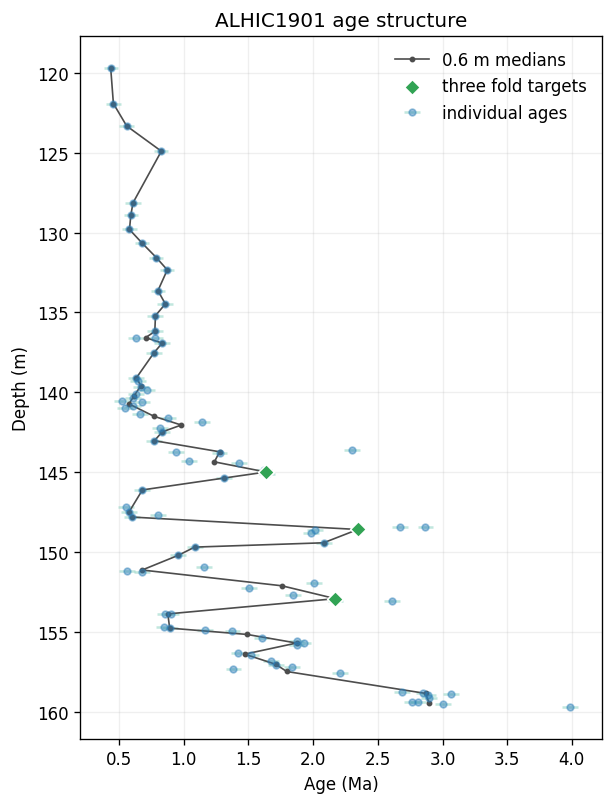

Loaded **88 ages**. The objective fold peaks are at 144.99 m (1.64 Ma), 148.58 m (2.35 Ma), 152.91 m (2.17 Ma).

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from IPython.display import Markdown, display
from scipy.optimize import differential_evolution
from scipy.signal import find_peaks
import firedrake as fd

logging.getLogger("tsfc").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.2})

data_path = Path("data/shackleton.pnas.2502681122.sd01.xlsx")
if not data_path.exists():
    data_path = Path("../data/shackleton.pnas.2502681122.sd01.xlsx")
workbook = openpyxl.load_workbook(data_path, read_only=True, data_only=True)
sheet = workbook["Ar and Water isotopes"]
rows = [
    (float(row[1]), float(row[8]), float(row[9]), float(row[10]))
    for row in sheet.iter_rows(min_row=3, values_only=True)
    if row[0] == "ALHIC1901" and isinstance(row[8], (int, float))
]
observations = np.asarray(sorted(rows), dtype=float)
depth, age, relative_error, absolute_error = observations.T

BIN_WIDTH = 0.6
bin_edges = np.arange(119.5, 160.1 + BIN_WIDTH, BIN_WIDTH)
bin_depth, bin_age = [], []
for left, right in zip(bin_edges[:-1], bin_edges[1:]):
    selected = (depth >= left) & (depth < right)
    if np.any(selected):
        bin_depth.append(np.mean(depth[selected]))
        bin_age.append(np.median(age[selected]))
bin_depth, bin_age = np.asarray(bin_depth), np.asarray(bin_age)
fold_bins = (bin_depth >= 141.0) & (bin_depth <= 155.0)
local_peak_indices = find_peaks(bin_age[fold_bins], prominence=0.3, distance=3)[0]
observed_peak_depths = bin_depth[fold_bins][local_peak_indices]
observed_peak_ages = bin_age[fold_bins][local_peak_indices]
assert len(observed_peak_depths) == 3

fig, ax = plt.subplots(figsize=(5.0, 6.6), constrained_layout=True)
ax.errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.48,
            color="#2c7fb8", ecolor="#7fcdbb", label="individual ages")
ax.plot(bin_age, bin_depth, ".-", color="0.3", lw=1, ms=5, label="0.6 m medians")
ax.scatter(observed_peak_ages, observed_peak_depths, marker="D", s=45,
           color="#31a354", edgecolor="white", zorder=5, label="three fold targets")
ax.invert_yaxis()
ax.set(xlabel="Age (Ma)", ylabel="Depth (m)", title="ALHIC1901 age structure")
ax.legend(frameon=False)
plt.show()

display(Markdown(
    f"Loaded **{len(age)} ages**. The objective fold peaks are at "
    + ", ".join(f"{d:.2f} m ({a:.2f} Ma)" for d, a in zip(observed_peak_depths, observed_peak_ages))
    + "."
))

## Mechanical model

Velocity $\mathbf{u}=(u,w)$ and pressure $p$ solve the steady, incompressible full-Stokes equations

$$-\nabla\cdot[2\eta(\dot\varepsilon_e)\,\mathrm{sym}(\nabla\mathbf{u})-p\mathbf{I}]=\rho\mathbf{g},\qquad \nabla\cdot\mathbf{u}=0,$$

with Glen exponent $n=3$ and $\eta=\tfrac12A^{-1/n}(\dot\varepsilon_e^2+\dot\varepsilon_0^2)^{(1-n)/(2n)}$. The parallel-sided slab is 2 km long, 160 m thick, and inclined by 0.03. Ice has density 917 kg m$^{-3}$ and strain-rate regularization $\dot\varepsilon_0=10^{-10}$ yr$^{-1}$. The softness is calibrated so the analytical n=3 slab retains the earlier model's 0.0138 m yr$^{-1}$ surface speed. The bed is no slip, the surface is stress free, and the sides use the analytical Glen slab velocity. P2--P1 elements resolve velocity and pressure. Coarse and fine meshes differ by a factor of two in both directions. These are plausible scales for a slow, locally steep Allan Hills flow band, not a site-specific temperature or softness inversion.

In [2]:
L, H = 2_000.0, 160.0       # m
RHO, G, ALPHA = 917.0, 9.81, 0.03
GLEN_N = 3.0
REFERENCE_MU = 2.5e8         # Pa yr; used only to retain the earlier surface speed
EPS_REG = 1e-10              # yr^-1
DURATION = 25_000.0          # yr
DRIVING = RHO * G * np.sin(ALPHA)
TARGET_SURFACE_SPEED = DRIVING * H**2 / (2 * REFERENCE_MU)
SOFTNESS = TARGET_SURFACE_SPEED * (GLEN_N + 1) / (
    2 * DRIVING**GLEN_N * H**(GLEN_N + 1)
)

def analytical_velocity(z):
    return 2 * SOFTNESS * DRIVING**GLEN_N / (GLEN_N + 1) * (
        H**(GLEN_N + 1) - (H - z)**(GLEN_N + 1)
    )

def solve_stokes(nx, nz):
    mesh = fd.RectangleMesh(nx, nz, L, H, quadrilateral=False)
    V = fd.VectorFunctionSpace(mesh, "CG", 2)
    Q = fd.FunctionSpace(mesh, "CG", 1)
    mixed = V * Q
    z = fd.SpatialCoordinate(mesh)[1]
    solution = fd.Function(mixed, name=f"glen_n3_{nx}_{nz}")
    u, p = fd.split(solution)
    v, q = fd.TestFunctions(mixed)
    strain = fd.sym(fd.grad(u))
    effective_strain = fd.sqrt(0.5 * fd.inner(strain, strain) + EPS_REG**2)
    viscosity = 0.5 * SOFTNESS**(-1 / GLEN_N) * effective_strain**((1 - GLEN_N) / GLEN_N)
    body_force = fd.Constant((RHO * G * np.sin(ALPHA), -RHO * G * np.cos(ALPHA)))
    residual = (
        2 * viscosity * fd.inner(strain, fd.sym(fd.grad(v)))
        - p * fd.div(v) - q * fd.div(u) - fd.dot(body_force, v)
    ) * fd.dx
    side_velocity = fd.as_vector((analytical_velocity(z), 0.0))
    bcs = [
        fd.DirichletBC(mixed.sub(0), side_velocity, 1),
        fd.DirichletBC(mixed.sub(0), side_velocity, 2),
        fd.DirichletBC(mixed.sub(0), fd.Constant((0.0, 0.0)), 3),
    ]
    solution.sub(0).interpolate(side_velocity)
    solution.sub(1).interpolate(RHO * G * np.cos(ALPHA) * (H - z))
    fd.solve(residual == 0, solution, bcs=bcs, solver_parameters={
        "snes_type": "newtonls", "snes_linesearch_type": "bt",
        "snes_rtol": 1e-9, "snes_max_it": 50,
        "ksp_type": "preonly", "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    })
    velocity, pressure = solution.subfunctions
    V1 = fd.VectorFunctionSpace(mesh, "CG", 1)
    Q1 = fd.FunctionSpace(mesh, "CG", 1)
    velocity_p1 = fd.Function(V1).interpolate(velocity)
    shear = fd.project(velocity[0].dx(1), Q1)
    divergence = fd.project(fd.div(velocity), Q1)
    normal = fd.FacetNormal(mesh)
    fluxes = np.array([float(fd.assemble(fd.dot(velocity, normal) * fd.ds(k))) for k in (1, 2, 3, 4)])
    gross_flux = np.sum(np.abs(fluxes))
    div_l2 = np.sqrt(float(fd.assemble(divergence**2 * fd.dx)))
    grad_l2 = np.sqrt(float(fd.assemble(fd.inner(fd.grad(velocity), fd.grad(velocity)) * fd.dx)))
    return {
        "solution": solution, "mesh": mesh, "velocity": velocity,
        "velocity_p1": velocity_p1, "pressure": pressure, "shear": shear,
        "max_speed": float(np.max(np.linalg.norm(velocity_p1.dat.data_ro, axis=1))),
        "max_shear": float(np.max(np.abs(shear.dat.data_ro))),
        "mass_residual": abs(np.sum(fluxes)) / gross_flux,
        "divergence_ratio": div_l2 / grad_l2, "nx": nx, "nz": nz,
    }

def centerline_profile(result, heights):
    points = np.column_stack((np.full_like(heights, L / 2), heights))
    values = np.asarray(result["velocity"].at(points, tolerance=1e-10))
    return values[:, 0]

coarse = solve_stokes(40, 8)
fine = solve_stokes(80, 16)
profile_heights = np.linspace(0.0, H, 1601)
coarse_u = centerline_profile(coarse, profile_heights)
fine_u = centerline_profile(fine, profile_heights)
analytic_u = analytical_velocity(profile_heights)

table = [
    f"Calibrated softness: **{SOFTNESS:.3e} Pa$^{{-3}}$ yr$^{{-1}}$**  ",
    "",
    "| Mesh | Maximum speed (m yr$^{-1}$) | Maximum $|u_z|$ (yr$^{-1}$) | Relative divergence | Flux residual |",
    "|---|---:|---:|---:|---:|",
]
for model in (coarse, fine):
    table.append(
        f"| {model['nx']} × {model['nz']} | {model['max_speed']:.5f} | "
        f"{model['max_shear']:.3e} | {model['divergence_ratio']:.3e} | "
        f"{model['mass_residual']:.3e} |"
    )
display(Markdown("\n".join(table)))

Calibrated softness: **2.146e-18 Pa$^{-3}$ yr$^{-1}$**  

| Mesh | Maximum speed (m yr$^{-1}$) | Maximum $|u_z|$ (yr$^{-1}$) | Relative divergence | Flux residual |
|---|---:|---:|---:|---:|
| 40 × 8 | 0.01382 | 3.428e-04 | 7.476e-16 | 1.803e-15 |
| 80 × 16 | 0.01382 | 3.447e-04 | 1.501e-15 | 3.871e-15 |

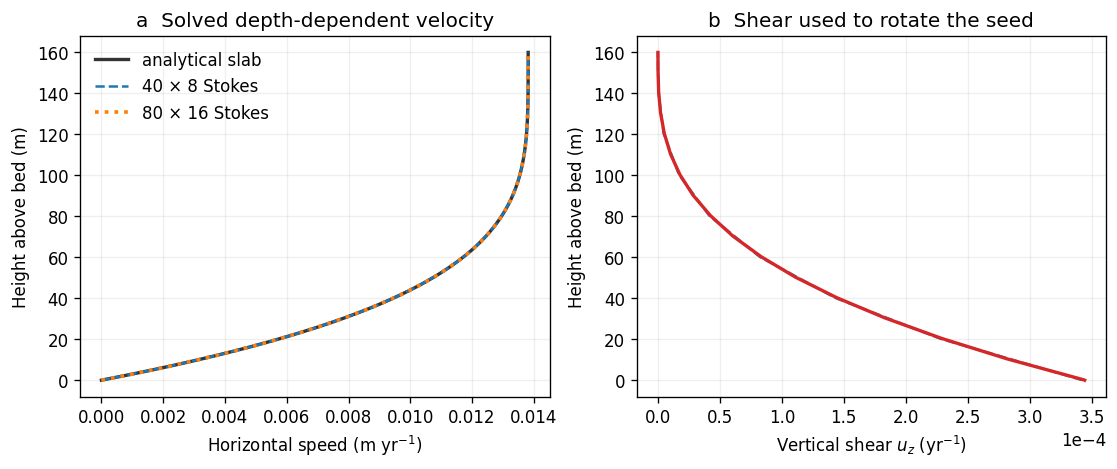

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
axes[0].plot(analytic_u, profile_heights, color="0.2", lw=2, label="analytical slab")
axes[0].plot(coarse_u, profile_heights, "--", lw=1.5, label="40 × 8 Stokes")
axes[0].plot(fine_u, profile_heights, ":", lw=2.2, label="80 × 16 Stokes")
axes[0].set(xlabel="Horizontal speed (m yr$^{-1}$)", ylabel="Height above bed (m)",
            title="a  Solved depth-dependent velocity")
axes[0].legend(frameon=False)
axes[1].plot(np.gradient(coarse_u, profile_heights), profile_heights, "--", lw=1.5)
axes[1].plot(np.gradient(fine_u, profile_heights), profile_heights, color="tab:red", lw=2)
axes[1].set(xlabel=r"Vertical shear $u_z$ (yr$^{-1}$)", ylabel="Height above bed (m)",
            title="b  Shear used to rotate the seed")
axes[1].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
plt.show()

## Compact inverse model

Let $S$ be an initially monotonic material coordinate, with larger $S$ representing younger, higher ice. The seed is

$$S_0(X,z)=z-A(z)\sin(2\pi X/\lambda+\phi),\qquad A(z)=b z\exp[-(z-z_c)^2/(2\sigma_z^2)].$$

The objective rejects any parameters for which $|A'(z)|\ge0.98$ or $A(z)/z\ge0.98$. Consequently $\partial S_0/\partial z>0.02$ for every phase: the seed can be nearly vertical, but it cannot contain an age reversal before deformation. In the steady slab, backtracking gives

$$S(x,z,T)=S_0(x-Tu(z),z).$$

A monotonic compressed basal age law, $a(S)=a_y+(4.0-a_y)\exp[-(S/\ell_a)^p]$, fixes the bed at 4.0 Ma and approaches $a_y$ upward. Eight fitted quantities are $(b,z_c,\sigma_z,\lambda,\phi,a_y,\ell_a,p)$. The objective combines density-weighted residuals to all 88 ages with the depths and amplitudes of the three independently identified peaks.

In [4]:
MODEL_ERROR = 0.15  # Ma
fold_depth_grid = np.linspace(139.5, 155.5, 1601)
depth_separation = depth[:, None] - depth[None, :]
sampling_density = np.exp(-0.5 * (depth_separation / 0.45)**2).sum(axis=1)
density_weights = 1.0 / sampling_density
density_weights /= density_weights.mean()

def sampled_u(heights, velocity_profile):
    return np.interp(np.asarray(heights), profile_heights, velocity_profile)

def amplitude_and_derivative(heights, parameters):
    bump, center, width = parameters[:3]
    heights = np.asarray(heights)
    gaussian = np.exp(-0.5 * ((heights - center) / width)**2)
    amplitude = bump * heights * gaussian
    derivative = bump * gaussian * (1 - heights * (heights - center) / width**2)
    return amplitude, derivative

def age_curve(parameters, depths, velocity_profile):
    bump, center, width, wavelength, phase, young_age, age_scale, age_power = parameters
    heights = H - np.asarray(depths)
    amplitude, _ = amplitude_and_derivative(heights, parameters)
    theta = phase - 2 * np.pi * DURATION * sampled_u(heights, velocity_profile) / wavelength
    material_coordinate = heights - amplitude * np.sin(theta)
    return young_age + (4.0 - young_age) * np.exp(
        -(np.maximum(material_coordinate, 0.0) / age_scale)**age_power
    )

def fit_objective(parameters):
    check_heights = np.linspace(0.01, H, 1000)
    amplitude, derivative = amplitude_and_derivative(check_heights, parameters)
    violation = max(
        0.0,
        float(np.max(np.abs(derivative))) - 0.98,
        float(np.max(amplitude / check_heights)) - 0.98,
        -float(np.min(amplitude / check_heights)),
    )
    if violation > 0:
        return 1000.0 + 1000.0 * violation**2

    prediction = age_curve(parameters, depth, fine_u)
    sigma = np.sqrt(relative_error**2 + MODEL_ERROR**2)
    data_term = np.average(((prediction - age) / sigma)**2, weights=density_weights)

    fold_prediction = age_curve(parameters, fold_depth_grid, fine_u)
    peak_indices = find_peaks(fold_prediction, prominence=0.25, distance=180)[0]
    peak_indices = peak_indices[
        (fold_depth_grid[peak_indices] >= 141.0) & (fold_depth_grid[peak_indices] <= 155.3)
    ]
    if len(peak_indices) != 3:
        return data_term + 100.0 + 40.0 * abs(len(peak_indices) - 3)
    feature_term = np.mean(((fold_depth_grid[peak_indices] - observed_peak_depths) / 0.55)**2)
    feature_term += np.mean(((fold_prediction[peak_indices] - observed_peak_ages) / 0.30)**2)
    return data_term + feature_term

parameter_bounds = [
    (0.0, 2.0),              # dimensionless bump amplitude
    (5.0, 25.0),             # envelope center above bed (m)
    (1.0, 15.0),             # envelope width (m)
    (6.0, 80.0),             # horizontal wavelength (m)
    (0.0, 2 * np.pi),        # phase (rad)
    (0.35, 0.90),            # upper-core asymptotic age (Ma)
    (1.0, 30.0),             # basal age scale (m)
    (0.35, 2.20),            # basal age exponent
]
fit = differential_evolution(
    fit_objective, parameter_bounds, seed=9, popsize=15, maxiter=250,
    tol=1e-7, polish=True, updating="immediate", workers=1,
)
best = fit.x

In [5]:
prediction = age_curve(best, depth, fine_u)
fine_fold_curve = age_curve(best, fold_depth_grid, fine_u)
model_peak_indices = find_peaks(fine_fold_curve, prominence=0.25, distance=180)[0]
model_peak_indices = model_peak_indices[
    (fold_depth_grid[model_peak_indices] >= 141.0) & (fold_depth_grid[model_peak_indices] <= 155.3)
]
model_peak_depths = fold_depth_grid[model_peak_indices]
model_peak_ages = fine_fold_curve[model_peak_indices]
rmse = np.sqrt(np.mean((prediction - age)**2))
weighted_rmse = np.sqrt(np.average((prediction - age)**2, weights=density_weights))
coarse_prediction = age_curve(best, depth, coarse_u)
mesh_age_difference = np.max(np.abs(prediction - coarse_prediction))
check_heights = np.linspace(0.01, H, 4000)
seed_amplitude, seed_amplitude_derivative = amplitude_and_derivative(check_heights, best)
minimum_order_gradient = 1.0 - np.max(np.abs(seed_amplitude_derivative))

phase_grid = np.linspace(0.0, 2 * np.pi, 721)
Z, THETA = np.meshgrid(check_heights[check_heights <= 45], phase_grid, indexing="ij")
A, AP = amplitude_and_derivative(Z, best)
seed_slope = (2 * np.pi / best[3]) * A * np.cos(THETA) / (1 - AP * np.sin(THETA))
maximum_seed_dip = np.degrees(np.arctan(np.max(np.abs(seed_slope))))

names = ["bump $b$", "center $z_c$ (m)", "width $\sigma_z$ (m)",
         "wavelength $\lambda$ (m)", "phase $\phi$ (rad)",
         "young age $a_y$ (Ma)", "age scale $\ell_a$ (m)", "age exponent $p$"]
parameter_table = ["| Parameter | Fit |", "|---|---:|"]
parameter_table += [f"| {name} | {value:.4g} |" for name, value in zip(names, best)]
display(Markdown("\n".join(parameter_table)))

peak_comparison = ", ".join(
    f"{observed:.2f}/{modeled:.2f} m" for observed, modeled in zip(observed_peak_depths, model_peak_depths)
)
display(Markdown(
    f"The fit has **{len(model_peak_depths)} folds**, **{rmse:.3f} Ma** pointwise RMS misfit "
    f"and **{weighted_rmse:.3f} Ma** depth-density-weighted RMS misfit. Observed/modeled "
    f"peak depths are {peak_comparison}. Doubling both mesh dimensions changes the "
    f"predicted ages at the samples by at most **{mesh_age_difference:.2e} Ma**. The initial "
    f"material-coordinate gradient remains positive by **{minimum_order_gradient:.3f}**, but "
    f"the steepest seed limb dips **{maximum_seed_dip:.1f}°**."
))

| Parameter | Fit |
|---|---:|
| bump $b$ | 0.7827 |
| center $z_c$ (m) | 10.74 |
| width $\sigma_z$ (m) | 8.329 |
| wavelength $\lambda$ (m) | 27.42 |
| phase $\phi$ (rad) | 2.642 |
| young age $a_y$ (Ma) | 0.5521 |
| age scale $\ell_a$ (m) | 3.718 |
| age exponent $p$ | 0.5886 |

The fit has **3 folds**, **0.370 Ma** pointwise RMS misfit and **0.317 Ma** depth-density-weighted RMS misfit. Observed/modeled peak depths are 144.99/144.75 m, 148.58/148.82 m, 152.91/152.62 m. Doubling both mesh dimensions changes the predicted ages at the samples by at most **1.93e-02 Ma**. The initial material-coordinate gradient remains positive by **0.020**, but the steepest seed limb dips **81.1°**.

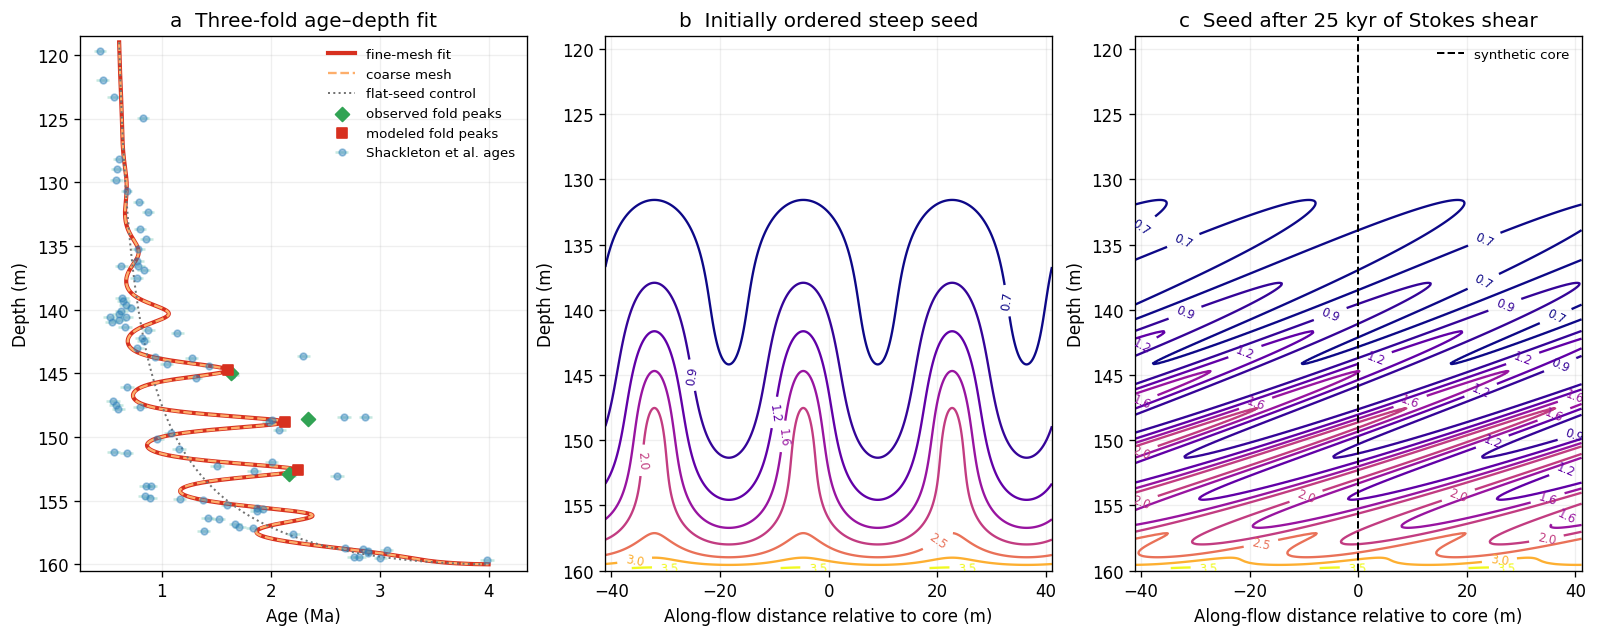

In [6]:
depth_line = np.linspace(119.0, 160.0, 2500)
fine_age_line = age_curve(best, depth_line, fine_u)
coarse_age_line = age_curve(best, depth_line, coarse_u)
flat_parameters = best.copy()
flat_parameters[0] = 0.0
flat_age_line = age_curve(flat_parameters, depth_line, fine_u)

x_local = np.linspace(-1.5 * best[3], 1.5 * best[3], 501)
z_local = np.linspace(0.2, 41.0, 401)
X, Z = np.meshgrid(x_local, z_local)
A, _ = amplitude_and_derivative(Z, best)

def section_age(time):
    theta = best[4] + 2 * np.pi * (X - time * sampled_u(Z, fine_u)) / best[3]
    material_coordinate = Z - A * np.sin(theta)
    return best[5] + (4.0 - best[5]) * np.exp(
        -(np.maximum(material_coordinate, 0.0) / best[6])**best[7]
    )

initial_section_age = section_age(0.0)
final_section_age = section_age(DURATION)
contour_levels = [0.7, 0.9, 1.2, 1.6, 2.0, 2.5, 3.0, 3.5]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 5.2), constrained_layout=True)
axes[0].errorbar(age, depth, xerr=relative_error, fmt="o", ms=4, alpha=0.45,
                 color="#2c7fb8", ecolor="#7fcdbb", label="Shackleton et al. ages")
axes[0].plot(fine_age_line, depth_line, color="#d7301f", lw=2.5, label="fine-mesh fit")
axes[0].plot(coarse_age_line, depth_line, color="#fdae6b", lw=1.4, ls="--", label="coarse mesh")
axes[0].plot(flat_age_line, depth_line, color="0.45", lw=1.2, ls=":", label="flat-seed control")
axes[0].scatter(observed_peak_ages, observed_peak_depths, marker="D", s=35, color="#31a354",
                zorder=5, label="observed fold peaks")
axes[0].scatter(model_peak_ages, model_peak_depths, marker="s", s=30, color="#d7301f",
                zorder=5, label="modeled fold peaks")
axes[0].set(xlabel="Age (Ma)", ylabel="Depth (m)", title="a  Three-fold age–depth fit",
            ylim=(160.5, 118.5), xlim=(0.25, 4.35))
axes[0].legend(frameon=False, fontsize=8, loc="upper right")

for axis, field, title in zip(
    axes[1:], [initial_section_age, final_section_age],
    ["b  Initially ordered steep seed", "c  Seed after 25 kyr of Stokes shear"],
):
    contours = axis.contour(X, H - Z, field, levels=contour_levels, cmap="plasma", linewidths=1.4)
    axis.clabel(contours, fmt="%.1f", fontsize=7)
    axis.set(xlabel="Along-flow distance relative to core (m)", ylabel="Depth (m)",
             title=title, ylim=(160.0, 119.0))
axes[2].axvline(0.0, color="black", ls="--", lw=1.2, label="synthetic core")
axes[2].legend(frameon=False, fontsize=8)
plt.show()

## Interpretation

This is a qualified positive result. A velocity obtained from a two-dimensional n=3 full-Stokes solve can shear one initially ordered basal disturbance into an age--depth curve with the observed three-fold spacing and broadly similar amplitudes. The flat-seed control remains monotonic, so depth-dependent shear is necessary but not sufficient.

The fit is also diagnostic about what it demands. It pushes the ordering constraint close to its bound and requires a seed limb that is nearly vertical before the 25 kyr shearing interval. Thus this notebook demonstrates the Waddington amplification mechanism and supplies a compact target geometry for the transient hypotheses; it does **not** show that ordinary steady flow spontaneously creates the ALHIC1901 structure. The single smooth curve cannot pass through all sample-scale scatter, and the second observed old-age lobe is slightly older than a strictly ordered seed naturally prefers.

The next discriminating calculation is to ask whether surface mass balance can generate the ordered seed and whether the same n=3 slab flow can subsequently reproduce the measured curve. Diffusion, three-dimensional flow, and the time at which old and Pleistocene ice first touched are not included here.